In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# 1. 导入数据集
print("=== 1. 导入数据集 ===")
df = pd.read_csv('rent_price_final_train_dataset2.csv')
print(f"数据集形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")

=== 1. 导入数据集 ===
数据集形状: (98899, 57)
列名: ['Price', 'lnPrice', 'decoration', 'high_dummy', 'middle_dummy', 'low_dummy', 'basement_dummy', 'total_floor', 'area', 'room_count', 'hall_count', 'south_dummy', 'north_south_dummy', 'pay_annual', 'pay_bi_monthly', 'pay_monthly', 'pay_quarterly', 'pay_semi_annual', 'rent_type_shared', 'elevator_yes', 'water_civil', 'water_commercial', 'electricity_civil', 'electricity_commercial', 'gas_yes', 'heating_self', 'lease_min_months', 'lease_max_months', 'lease_avg_months', 'facility_洗衣机', 'facility_空调', 'facility_衣柜', 'facility_电视', 'facility_冰箱', 'facility_热水器', 'facility_床', 'facility_天然气', 'facility_暖气', 'facility_宽带', 'building_age', 'household_total', 'building_total', 'greening_rate', 'plot_ratio', 'property_fee_avg', 'structure_tower', 'structure_slab', 'structure_combined', 'structure_bungalow', 'gas_fee_avg', 'heating_fee_avg', 'parking_spots', '城市', '区县', '板块', '距市中心距离_km', 'property_phone_yes']


In [5]:
# 2. 创建城市哑变量
print("\n=== 2. 创建城市哑变量 ===")

if '城市' in df.columns:
    # 删除可能已存在的城市哑变量
    city_dummy_cols = [col for col in df.columns if col.startswith('city_')]
    if city_dummy_cols:
        df.drop(city_dummy_cols, axis=1, inplace=True)
        print(f"已删除已存在的城市哑变量: {city_dummy_cols}")
    
    # 获取城市唯一值并排序
    unique_cities = sorted(df['城市'].unique())
    print(f"城市唯一值: {unique_cities}")
    
    # 创建城市哑变量
    for city_num in unique_cities:
        col_name = f'city_{city_num}'
        df[col_name] = (df['城市'] == city_num).astype(int)
    
    # 验证创建结果
    created_city_cols = [col for col in df.columns if col.startswith('city_')]
    print(f"已创建 {len(created_city_cols)} 个城市哑变量: {created_city_cols}")
    
    # 显示每个城市哑变量的样本数量
    for col in created_city_cols:
        count = df[col].sum()
        print(f"{col}: {count} 个样本")
else:
    print("数据集中没有'城市'列，无法创建城市哑变量")

# 3. 创建城市与距离的交互项
print("\n=== 3. 创建城市与距离的交互项 ===")

if '城市' in df.columns and '距市中心距离_km' in df.columns:
    # 删除可能已存在的交互项
    interaction_cols = [col for col in df.columns if col.startswith('city_dist_')]
    if interaction_cols:
        df.drop(interaction_cols, axis=1, inplace=True)
        print(f"已删除已存在的交互项: {interaction_cols}")
    
    # 为每个城市创建与距离的交互项
    for city_num in unique_cities:
        col_name = f'city_dist_{city_num}'
        df[col_name] = df[f'city_{city_num}'] * df['距市中心距离_km']
    
    # 验证创建结果
    created_interaction_cols = [col for col in df.columns if col.startswith('city_dist_')]
    print(f"已创建 {len(created_interaction_cols)} 个城市-距离交互项: {created_interaction_cols}")
    
    # 显示交互项的基本统计信息
    for col in created_interaction_cols:
        non_zero_count = (df[col] != 0).sum()
        print(f"{col}: {non_zero_count} 个非零值, 均值={df[col].mean():.2f}")
else:
    print("缺少'城市'或'距市中心距离_km'列，无法创建交互项")



=== 2. 创建城市哑变量 ===
城市唯一值: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
已创建 12 个城市哑变量: ['city_0', 'city_1', 'city_2', 'city_3', 'city_4', 'city_5', 'city_6', 'city_7', 'city_8', 'city_9', 'city_10', 'city_11']
city_0: 14542 个样本
city_1: 7725 个样本
city_2: 12059 个样本
city_3: 15550 个样本
city_4: 11796 个样本
city_5: 4077 个样本
city_6: 1020 个样本
city_7: 10211 个样本
city_8: 7274 个样本
city_9: 1255 个样本
city_10: 12979 个样本
city_11: 411 个样本

=== 3. 创建城市与距离的交互项 ===
已创建 12 个城市-距离交互项: ['city_dist_0', 'city_dist_1', 'city_dist_2', 'city_dist_3', 'city_dist_4', 'city_dist_5', 'city_dist_6', 'city_dist_7', 'city_dist_8', 'city_dist_9', 'city_dist_10', 'city_dist_11']
city_dist_0: 14542 个非零值, 均值=21.71
city_dist_1: 7725 个非零值, 均值=12.10
city_dist_2: 12059 个非零值, 均值=22.15
city_dist_3: 15550 个非零值, 均值=3.63
city_dist_4: 11796 个非零值, 均值=17.42
city_dist_5: 4077 个非零值, 均值=5.91
city_dist_6: 1020 个非零值, 均值=1.51
city_dis

In [6]:
from collections import Counter

# 4. 使用IQR方法剔除离群点
print("\n=== 4. 使用IQR方法剔除离群点 ===")

# 根据租房数据变量列表识别连续型自变量
continuous_vars = []
# 排除因变量、哑变量和分类变量
exclude_vars = ['Price', 'lnPrice', 'decoration', 'rent_type_shared', 'property_phone_yes'] + \
               [col for col in df.columns if col.startswith('city_') or 
                col.endswith('_dummy') or 
                col.startswith('facility_') or
                col.startswith('pay_') or
                col.startswith('structure_') or
                col.startswith('water_') or
                col.startswith('electricity_') or
                col in ['gas_yes', 'heating_self']]

# 从租房变量列表中选择连续型变量
rent_continuous_candidates = [
    'area', 'room_count', 'hall_count', 'lease_min_months', 'lease_max_months', 
    'lease_avg_months', 'building_age', 'household_total', 'building_total', 
    'greening_rate', 'plot_ratio', 'property_fee_avg', 'gas_fee_avg', 
    'heating_fee_avg', 'parking_spots', 'total_floor', '距市中心距离_km'
]

for col in rent_continuous_candidates:
    if col in df.columns:
        if df[col].nunique() > 10 and col not in exclude_vars:
            continuous_vars.append(col)

print(f"连续型自变量数量: {len(continuous_vars)}")
print(f"连续型自变量: {continuous_vars}")

# 使用IQR方法识别离群点
def detect_outliers_iqr(df, columns, multiplier=3):
    outlier_indices = set()
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # 找出离群点的索引
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
        
        print(f"{col}: 离群点数量 = {len(outliers)} (边界: [{lower_bound:.2f}, {upper_bound:.2f}])")
    
    return list(outlier_indices)

# 使用系数3检测离群点，但只对自变量
outlier_indices = detect_outliers_iqr(df, continuous_vars, multiplier=3)
print(f"\n总共检测到 {len(outlier_indices)} 个离群点")

# 计算每个样本的离群点数量，只剔除有多个离群点的样本
outlier_counts = Counter(outlier_indices)

# 设置阈值：如果一个样本在多个变量上都是离群点，则剔除
threshold = 2
extreme_outliers = [idx for idx, count in outlier_counts.items() if count >= threshold]

print(f"有 {len(extreme_outliers)} 个样本在 {threshold} 个或以上变量上是离群点")

# 剔除极端离群点
original_shape = df.shape
df_clean = df.drop(extreme_outliers)
print(f"剔除离群点后数据集形状: {original_shape} -> {df_clean.shape}")
print(f"剔除了 {len(extreme_outliers)} 行数据，占总数据的 {len(extreme_outliers)/original_shape[0]*100:.2f}%")



=== 4. 使用IQR方法剔除离群点 ===
连续型自变量数量: 16
连续型自变量: ['area', 'room_count', 'lease_min_months', 'lease_max_months', 'lease_avg_months', 'building_age', 'household_total', 'building_total', 'greening_rate', 'plot_ratio', 'property_fee_avg', 'gas_fee_avg', 'heating_fee_avg', 'parking_spots', 'total_floor', '距市中心距离_km']
area: 离群点数量 = 724 (边界: [-98.44, 248.48])
room_count: 离群点数量 = 98 (边界: [-1.00, 6.00])
lease_min_months: 离群点数量 = 11476 (边界: [1.00, 1.00])
lease_max_months: 离群点数量 = 0 (边界: [-24.00, 60.00])
lease_avg_months: 离群点数量 = 1729 (边界: [-11.50, 30.50])
building_age: 离群点数量 = 7 (边界: [-42.00, 77.00])
household_total: 离群点数量 = 979 (边界: [-4629.00, 7999.00])
building_total: 离群点数量 = 5215 (边界: [-54.00, 86.00])
greening_rate: 离群点数量 = 7849 (边界: [0.00, 0.00])
plot_ratio: 离群点数量 = 2668 (边界: [-2.34, 7.53])
property_fee_avg: 离群点数量 = 2236 (边界: [-4.84, 8.67])
gas_fee_avg: 离群点数量 = 0 (边界: [0.09, 5.97])
heating_fee_avg: 离群点数量 = 22985 (边界: [-9.00, 15.50])
parking_spots: 离群点数量 = 3923 (边界: [-3400.00, 5000.00])
total_f


=== 5. 探究自变量与lnPrice的关系 ===

所有变量与lnPrice的相关系数（绝对值）:
Price: 0.821
area: 0.438
lease_max_months: 0.424
city_dist_0: 0.414
city_0: 0.414
lease_avg_months: 0.379
city_dist_4: 0.336
city_4: 0.335
city_2: 0.292
city_dist_2: 0.290
rent_type_shared: 0.279
city_1: 0.277
city_dist_1: 0.270
property_phone_yes: 0.267
gas_fee_avg: 0.230
heating_fee_avg: 0.201
city_7: 0.191
structure_slab: 0.190
city_dist_7: 0.187
city_dist_8: 0.187
city_8: 0.186
facility_空调: 0.180
pay_semi_annual: 0.174
household_total: 0.165
hall_count: 0.160
property_fee_avg: 0.144
区县: 0.140
city_6: 0.135
city_dist_6: 0.133
facility_电视: 0.131
building_age: 0.131
facility_暖气: 0.119
electricity_civil: 0.117
city_dist_3: 0.116
parking_spots: 0.116
pay_annual: 0.115
城市: 0.113
water_civil: 0.113
north_south_dummy: 0.110
city_3: 0.110
facility_衣柜: 0.109
electricity_commercial: 0.107
city_9: 0.104
water_commercial: 0.103
decoration: 0.102
room_count: 0.102
pay_monthly: 0.099
lease_min_months: 0.092
pay_quarterly: 0.090
south_dummy: 0.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:40: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:40: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:40: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:40: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\lenovo\AppData\Local\Progra

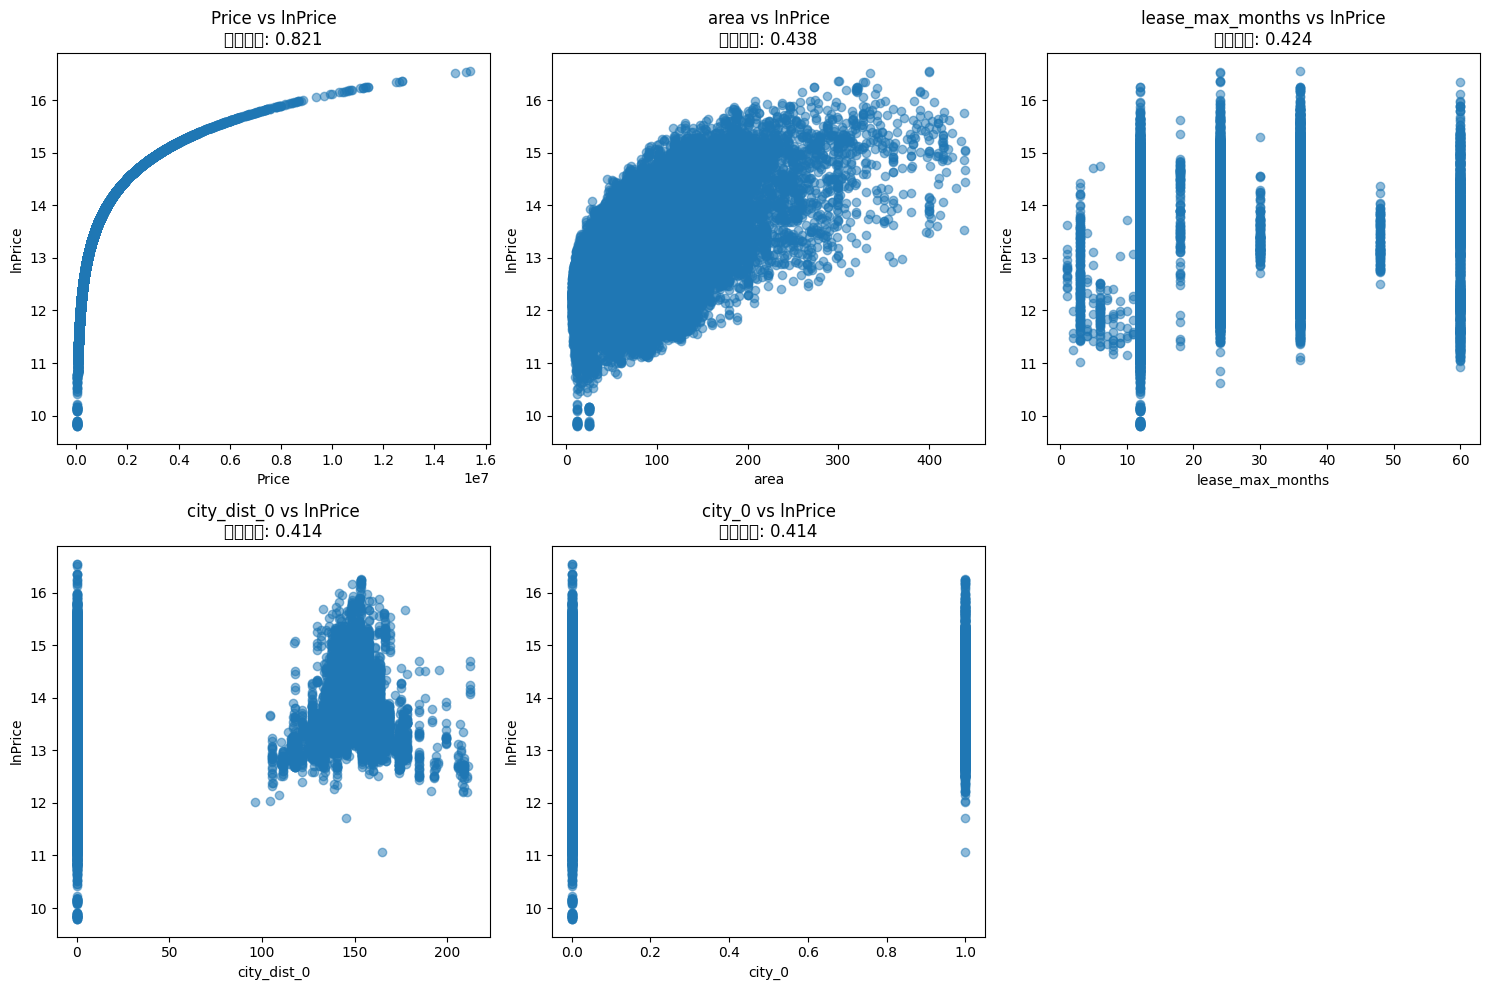

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:50: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:50: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:50: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_8312\1745243820.py:50: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


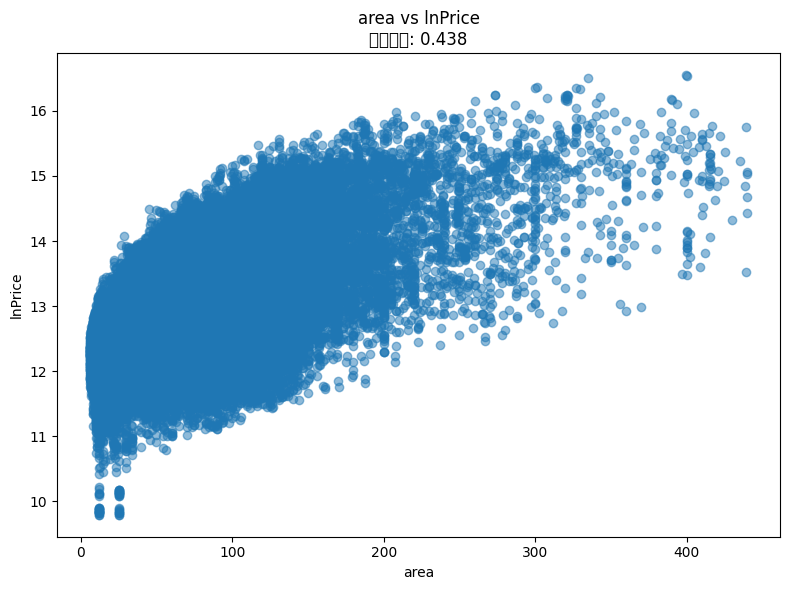


=== 6. 保存最终数据集 ===
数据集已保存为 rent_price_final_train_dataset3.csv
最终数据集形状: (98899, 81)

数据集简要统计信息:
              Price       lnPrice    decoration    high_dummy  middle_dummy  \
count  9.889900e+04  98899.000000  98899.000000  98899.000000  98899.000000   
mean   5.829090e+05     12.959105      0.256929      0.318011      0.358709   
std    6.218424e+05      0.758831      0.436942      0.465706      0.479624   
min    1.793807e+04      9.794681      0.000000      0.000000      0.000000   
25%    2.416282e+05     12.395155      0.000000      0.000000      0.000000   
50%    3.949369e+05     12.886481      0.000000      0.000000      0.000000   
75%    7.248954e+05     13.493783      1.000000      1.000000      1.000000   
max    1.540419e+07     16.550150      1.000000      1.000000      1.000000   

          low_dummy  basement_dummy   total_floor          area    room_count  \
count  98899.000000    98899.000000  98899.000000  98899.000000  98899.000000   
mean       0.269194        0.

In [7]:
# 5. 探究自变量与因变量lnPrice的关系
print("\n=== 5. 探究自变量与lnPrice的关系 ===")

# 检查是否有lnPrice列，如果没有则创建
if 'lnPrice' not in df_clean.columns and 'Price' in df_clean.columns:
    df_clean['lnPrice'] = np.log(df_clean['Price'])
    print("已创建lnPrice变量")

if 'lnPrice' in df_clean.columns:
    # 计算所有数值变量与lnPrice的相关系数
    numeric_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    correlations = df_clean[numeric_cols_clean].corr()['lnPrice'].abs().sort_values(ascending=False)
    
    print("\n所有变量与lnPrice的相关系数（绝对值）:")
    for var, corr in correlations.items():
        if var != 'lnPrice':
            print(f"{var}: {corr:.3f}")
    
    # 选择与lnPrice相关性最高的几个变量绘制散点图
    top_vars = correlations[1:6].index.tolist()
    
    print(f"\n绘制与lnPrice相关性最高的 {len(top_vars)} 个变量的散点图:")
    print(top_vars)
    
    # 绘制散点图
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, var in enumerate(top_vars):
        if i < len(axes):
            axes[i].scatter(df_clean[var], df_clean['lnPrice'], alpha=0.5)
            axes[i].set_xlabel(var)
            axes[i].set_ylabel('lnPrice')
            axes[i].set_title(f'{var} vs lnPrice\n相关系数: {correlations[var]:.3f}')
    
    # 隐藏多余的子图
    for i in range(len(top_vars), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 绘制area与lnPrice的关系
    if 'area' in df_clean.columns:
        plt.figure(figsize=(8, 6))
        plt.scatter(df_clean['area'], df_clean['lnPrice'], alpha=0.5)
        plt.xlabel('area')
        plt.ylabel('lnPrice')
        plt.title(f'area vs lnPrice\n相关系数: {correlations["area"]:.3f}')
        plt.tight_layout()
        plt.show()
else:
    print("数据集中没有lnPrice或Price变量，无法进行相关性分析")

# 6. 保存最终数据集
print("\n=== 6. 保存最终数据集 ===")
df_clean.to_csv("rent_price_final_train_dataset3.csv", index=False)
print("数据集已保存为 rent_price_final_train_dataset3.csv")
print(f"最终数据集形状: {df_clean.shape}")

print("\n数据集简要统计信息:")
print(df_clean.describe())

print("\n=== 租房数据特征工程处理完成 ===")